# ODIR-5K: Chia tập & Tiền xử lý Offline

Notebook này thực hiện:
1. **Chia tập theo bệnh nhân** (patient-level, multi-label stratified): 70% train / 20% val / 10% test
2. **Tiền xử lý offline**: Graham's method + resize 299×299 cho tất cả ảnh
3. **Augmentation** (chỉ tập train): 6 kiểu biến đổi
4. Lưu `split_metadata.csv` và `class_weights.json`

⚠️ **Cảnh báo**: Notebook này ghi ~2 GB dữ liệu ra đĩa. Thời gian chạy: 20–40 phút.

In [3]:
import os
import json
import shutil
import numpy as np
import pandas as pd
import cv2
from PIL import Image, ImageOps, ImageEnhance
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

try:
    from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
    print('iterstrat loaded OK')
except ImportError:
    print('iterstrat not found. Install: pip install iterative-stratification')
    raise

try:
    from tqdm import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

PROJECT_ROOT = '/home/centrala/work/ou/kltn/Ocular-Disease-Recognition'
DATA_XLSX    = f'{PROJECT_ROOT}/odir-data/data.xlsx'
IMAGE_DIR    = f'{PROJECT_ROOT}/odir-data/crop_training_images'
OUTPUT_BASE  = f'{PROJECT_ROOT}/odir-data-preprocess-augmentation'
MODEL_DIR    = f'{PROJECT_ROOT}/model_v2'

TARGET_COLS  = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
IMAGE_SIZE   = 299
RANDOM_SEED  = 42
AUG_IDS      = [0, 1, 2, 3, 4, 5]  # 6 kiểu augmentation

print('Setup OK')

iterstrat loaded OK
Setup OK


## 1. Tạo thư mục đầu ra

In [4]:
for split in ['train', 'val', 'test']:
    os.makedirs(f'{OUTPUT_BASE}/{split}', exist_ok=True)

print('Thư mục đầu ra:')
for split in ['train', 'val', 'test']:
    print(f'  {OUTPUT_BASE}/{split}/')

Thư mục đầu ra:
  /home/centrala/work/ou/kltn/Ocular-Disease-Recognition/odir-data-preprocess-augmentation/train/
  /home/centrala/work/ou/kltn/Ocular-Disease-Recognition/odir-data-preprocess-augmentation/val/
  /home/centrala/work/ou/kltn/Ocular-Disease-Recognition/odir-data-preprocess-augmentation/test/


## 2. Load dữ liệu và kiểm tra ảnh

In [5]:
df_raw = pd.read_excel(DATA_XLSX)
print(f'Dữ liệu gốc: {len(df_raw)} bệnh nhân')
print(f'Columns: {df_raw.columns.tolist()}')

# Kiểm tra ảnh tồn tại
valid_indices = []
missing = []
for idx, row in df_raw.iterrows():
    pid = row['ID']
    left  = f'{IMAGE_DIR}/{pid}_left.jpg'
    right = f'{IMAGE_DIR}/{pid}_right.jpg'
    if os.path.exists(left) and os.path.exists(right):
        valid_indices.append(idx)
    else:
        missing.append(pid)

df = df_raw.loc[valid_indices].reset_index(drop=True)
print(f'Bệnh nhân hợp lệ (có đủ 2 ảnh): {len(df)}')
if missing:
    print(f'Thiếu ảnh: {missing[:10]}...')

Dữ liệu gốc: 3500 bệnh nhân
Columns: ['ID', 'Patient Age', 'Patient Sex', 'Left-Fundus', 'Right-Fundus', 'Left-Diagnostic Keywords', 'Right-Diagnostic Keywords', 'N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']
Bệnh nhân hợp lệ (có đủ 2 ảnh): 3500


## 3. Multi-label Stratified Split (theo bệnh nhân)

**Tại sao phải chia theo bệnh nhân?**  
Mỗi bệnh nhân có ảnh mắt trái + mắt phải. Nếu chia theo ảnh, 2 mắt của cùng bệnh nhân có thể rơi vào train và test → **data leakage**.

In [6]:
label_matrix = df[TARGET_COLS].values  # [N_patients, 8]
indices      = np.arange(len(df))

# Bước 1: 90% trainval / 10% test
msss1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.10, random_state=RANDOM_SEED)
for trainval_local, test_local in msss1.split(indices.reshape(-1, 1), label_matrix):
    pass

# Bước 2: từ 90%, chia train/val: test_size=0.222 → ~20% tổng
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.222, random_state=RANDOM_SEED)
label_trainval = label_matrix[trainval_local]
for train_local, val_local in msss2.split(trainval_local.reshape(-1, 1), label_trainval):
    pass

# Ánh xạ về chỉ số gốc
train_idx = trainval_local[train_local]
val_idx   = trainval_local[val_local]
test_idx  = test_local

train_df = df.iloc[train_idx].reset_index(drop=True)
val_df   = df.iloc[val_idx].reset_index(drop=True)
test_df  = df.iloc[test_idx].reset_index(drop=True)

total = len(df)
print(f'Train: {len(train_df)} bệnh nhân ({len(train_df)/total*100:.1f}%)')
print(f'Val:   {len(val_df)} bệnh nhân ({len(val_df)/total*100:.1f}%)')
print(f'Test:  {len(test_df)} bệnh nhân ({len(test_df)/total*100:.1f}%)')

Train: 2453 bệnh nhân (70.1%)
Val:   697 bệnh nhân (19.9%)
Test:  350 bệnh nhân (10.0%)


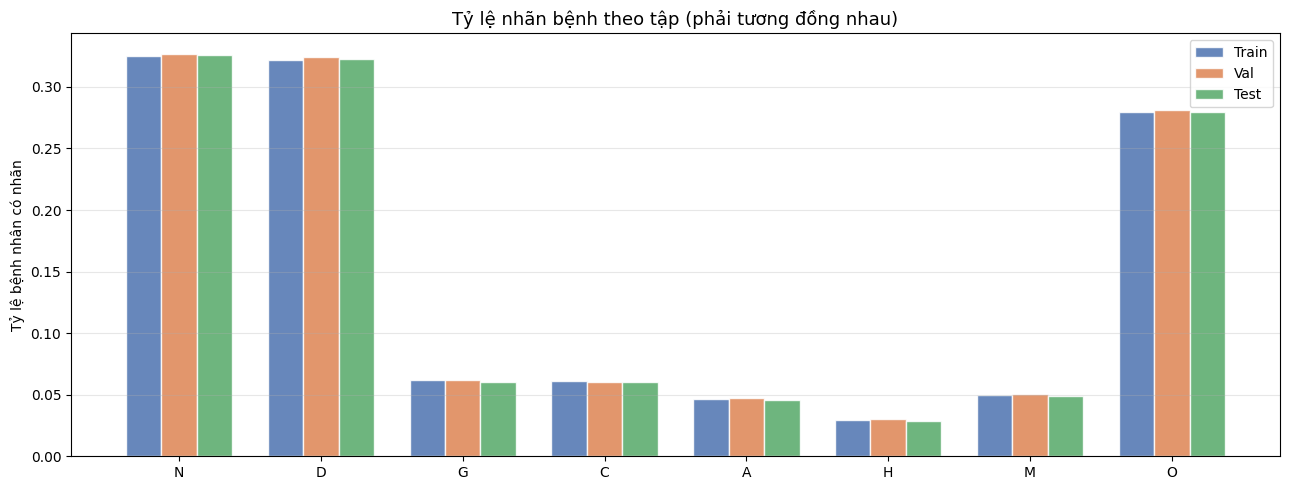

Saved: chart_split_verification.png


In [7]:
# Kiểm tra chất lượng stratification
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(TARGET_COLS))
w = 0.25
splits_info = [('Train', train_df, '#4C72B0'), ('Val', val_df, '#DD8452'), ('Test', test_df, '#55A868')]
for i, (name, split, color) in enumerate(splits_info):
    rates = split[TARGET_COLS].mean().values
    bars  = ax.bar(x + i * w, rates, w, label=name, color=color, alpha=0.85, edgecolor='white')

ax.set_xticks(x + w)
ax.set_xticklabels(TARGET_COLS)
ax.set_title('Tỷ lệ nhãn bệnh theo tập (phải tương đồng nhau)', fontsize=13)
ax.set_ylabel('Tỷ lệ bệnh nhân có nhãn')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/chart_split_verification.png', dpi=120)
plt.show()
print('Saved: chart_split_verification.png')

## 4. Hàm tiền xử lý và augmentation

In [8]:
def graham_preprocess(img_bgr, image_size=299, sigma_ratio=30):
    """
    Ben Graham's contrast normalization for fundus images.
    Formula: out = addWeighted(img, 4, GaussianBlur(img, sigma), -4, 128)
    Sigma = image_size / sigma_ratio (~10 for 299x299)
    """
    sigma   = image_size / sigma_ratio
    blurred = cv2.GaussianBlur(img_bgr, (0, 0), sigma)
    output  = cv2.addWeighted(img_bgr, 4, blurred, -4, 128)
    output  = cv2.resize(output, (image_size, image_size))
    return output


def load_and_preprocess(img_path, image_size=299):
    """Load ảnh, áp dụng Graham, trả về PIL Image RGB."""
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise FileNotFoundError(f'Cannot read: {img_path}')
    processed = graham_preprocess(img_bgr, image_size)
    img_rgb   = cv2.cvtColor(processed, cv2.COLOR_BGR2RGB)
    return Image.fromarray(img_rgb)


def augment_image(pil_img, aug_id):
    """
    Áp dụng augmentation theo aug_id:
    0: Lật ngang (horizontal flip)
    1: Lật dọc (vertical flip)
    2: Xoay +15°
    3: Xoay -15°
    4: Tăng độ sáng 20%
    5: Tăng độ tương phản 20%
    """
    if aug_id == 0:
        return ImageOps.mirror(pil_img)
    elif aug_id == 1:
        return ImageOps.flip(pil_img)
    elif aug_id == 2:
        return pil_img.rotate(15, resample=Image.BILINEAR, expand=False)
    elif aug_id == 3:
        return pil_img.rotate(-15, resample=Image.BILINEAR, expand=False)
    elif aug_id == 4:
        return ImageEnhance.Brightness(pil_img).enhance(1.2)
    elif aug_id == 5:
        return ImageEnhance.Contrast(pil_img).enhance(1.2)
    return pil_img


print('Hàm tiền xử lý và augmentation OK')

Hàm tiền xử lý và augmentation OK


## 5. Lưu tập Val và Test (chỉ Graham, không augment)

In [9]:
def process_and_save_split(split_df, split_name, image_size=299):
    """Tiền xử lý và lưu val/test (không augmentation)."""
    out_dir = f'{OUTPUT_BASE}/{split_name}'
    records = []
    for _, row in tqdm(split_df.iterrows(), total=len(split_df), desc=split_name):
        pid = row['ID']
        for side in ['left', 'right']:
            src = f'{IMAGE_DIR}/{pid}_{side}.jpg'
            dst = f'{out_dir}/{pid}_{side}.jpg'
            img = load_and_preprocess(src, image_size)
            img.save(dst, 'JPEG', quality=95)
        records.append({
            'patient_id': pid,
            'split':      split_name,
            'aug_id':     -1,
            'left_path':  f'{out_dir}/{pid}_left.jpg',
            'right_path': f'{out_dir}/{pid}_right.jpg',
            'age':        row['Patient Age'],
            'gender':     row['Patient Sex'],
            **{col: int(row[col]) for col in TARGET_COLS}
        })
    return records

print('Xử lý tập Val...')
val_records  = process_and_save_split(val_df,  'val')
print(f'  Val: {len(val_records)} bệnh nhân, {len(val_records)*2} ảnh')

print('Xử lý tập Test...')
test_records = process_and_save_split(test_df, 'test')
print(f'  Test: {len(test_records)} bệnh nhân, {len(test_records)*2} ảnh')

Xử lý tập Val...


val: 100%|██████████| 697/697 [00:13<00:00, 50.48it/s]


  Val: 697 bệnh nhân, 1394 ảnh
Xử lý tập Test...


test: 100%|██████████| 350/350 [00:09<00:00, 36.07it/s]

  Test: 350 bệnh nhân, 700 ảnh


## 6. Lưu tập Train (Graham + 6 bản Augmented)

In [10]:
def process_and_save_train(train_df, image_size=299):
    """Tiền xử lý và lưu train: ảnh gốc + 6 bản augmented."""
    out_dir = f'{OUTPUT_BASE}/train'
    records = []
    for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc='train'):
        pid = row['ID']
        base_info = {
            'patient_id': pid,
            'split':      'train',
            'age':        row['Patient Age'],
            'gender':     row['Patient Sex'],
            **{col: int(row[col]) for col in TARGET_COLS}
        }

        # Load và tiền xử lý ảnh gốc
        left_base  = load_and_preprocess(f'{IMAGE_DIR}/{pid}_left.jpg',  image_size)
        right_base = load_and_preprocess(f'{IMAGE_DIR}/{pid}_right.jpg', image_size)

        # Lưu ảnh gốc (aug_id = -1)
        left_base.save(f'{out_dir}/{pid}_left.jpg',  'JPEG', quality=95)
        right_base.save(f'{out_dir}/{pid}_right.jpg', 'JPEG', quality=95)
        records.append({
            **base_info,
            'aug_id':     -1,
            'left_path':  f'{out_dir}/{pid}_left.jpg',
            'right_path': f'{out_dir}/{pid}_right.jpg',
        })

        # Lưu 6 bản augmented
        for aug_id in AUG_IDS:
            aug_left  = augment_image(left_base,  aug_id)
            aug_right = augment_image(right_base, aug_id)
            left_dst  = f'{out_dir}/{pid}_left_aug{aug_id}.jpg'
            right_dst = f'{out_dir}/{pid}_right_aug{aug_id}.jpg'
            aug_left.save(left_dst,  'JPEG', quality=95)
            aug_right.save(right_dst, 'JPEG', quality=95)
            records.append({
                **base_info,
                'aug_id':     aug_id,
                'left_path':  left_dst,
                'right_path': right_dst,
            })
    return records

print('Xử lý tập Train (gốc + 6 augmented)...')
train_records = process_and_save_train(train_df)
n_patients = len(train_df)
n_images   = len(train_records) * 2
print(f'  Train: {n_patients} bệnh nhân × 7 bản = {len(train_records)} records, {n_images} ảnh')

Xử lý tập Train (gốc + 6 augmented)...


train: 100%|██████████| 2453/2453 [01:53<00:00, 21.66it/s]

  Train: 2453 bệnh nhân × 7 bản = 17171 records, 34342 ảnh


## 7. Tạo và lưu split_metadata.csv

In [11]:
all_records = train_records + val_records + test_records
meta_df = pd.DataFrame(all_records)

col_order = ['patient_id', 'split', 'aug_id', 'left_path', 'right_path',
             'age', 'gender'] + TARGET_COLS
meta_df = meta_df[col_order]

meta_path = f'{OUTPUT_BASE}/split_metadata.csv'
meta_df.to_csv(meta_path, index=False)

print(f'Saved: {meta_path}')
print(f'Total rows: {len(meta_df)}')
print('\nRows per split:')
print(meta_df.groupby('split')['patient_id'].count())
print('\nRows per split (aug_id = -1 only = base images):')
print(meta_df[meta_df['aug_id'] == -1].groupby('split')['patient_id'].count())

Saved: /home/centrala/work/ou/kltn/Ocular-Disease-Recognition/odir-data-preprocess-augmentation/split_metadata.csv
Total rows: 18218

Rows per split:
split
test       350
train    17171
val        697
Name: patient_id, dtype: int64

Rows per split (aug_id = -1 only = base images):
split
test      350
train    2453
val       697
Name: patient_id, dtype: int64


## 8. Tính Class Weights từ tập Train (chỉ ảnh gốc)

In [12]:
# QUAN TRỌNG: tính từ base train (aug_id == -1) để tránh inflate N_pos
train_base = meta_df[(meta_df['split'] == 'train') & (meta_df['aug_id'] == -1)]
N_train = len(train_base)

LABEL_NAMES = {
    'N': 'Normal', 'D': 'Diabetic Retinopathy', 'G': 'Glaucoma',
    'C': 'Cataract', 'A': 'AMD', 'H': 'Hypertension', 'M': 'Myopia', 'O': 'Other'
}

class_weights = {}
print('Class weights (pos_weight cho BCEWithLogitsLoss, từ tập train):')
print(f'{"Label":<5} {"N_pos":>6} {"N_neg":>6} {"Weight":>8}')
print('-' * 30)
for col in TARGET_COLS:
    n_pos = int(train_base[col].sum())
    n_neg = N_train - n_pos
    weight = round(n_neg / n_pos, 4) if n_pos > 0 else 1.0
    class_weights[col] = weight
    print(f'{col:<5} {n_pos:>6} {n_neg:>6} {weight:>8.2f}')

weights_path = f'{OUTPUT_BASE}/class_weights.json'
with open(weights_path, 'w') as f:
    json.dump(class_weights, f, indent=2)
print(f'\nSaved: {weights_path}')

Class weights (pos_weight cho BCEWithLogitsLoss, từ tập train):
Label  N_pos  N_neg   Weight
------------------------------
N        798   1655     2.07
D        789   1664     2.11
G        151   2302    15.24
C        149   2304    15.46
A        115   2338    20.33
H         72   2381    33.07
M        122   2331    19.11
O        685   1768     2.58

Saved: /home/centrala/work/ou/kltn/Ocular-Disease-Recognition/odir-data-preprocess-augmentation/class_weights.json


## 9. Kiểm tra visual kết quả

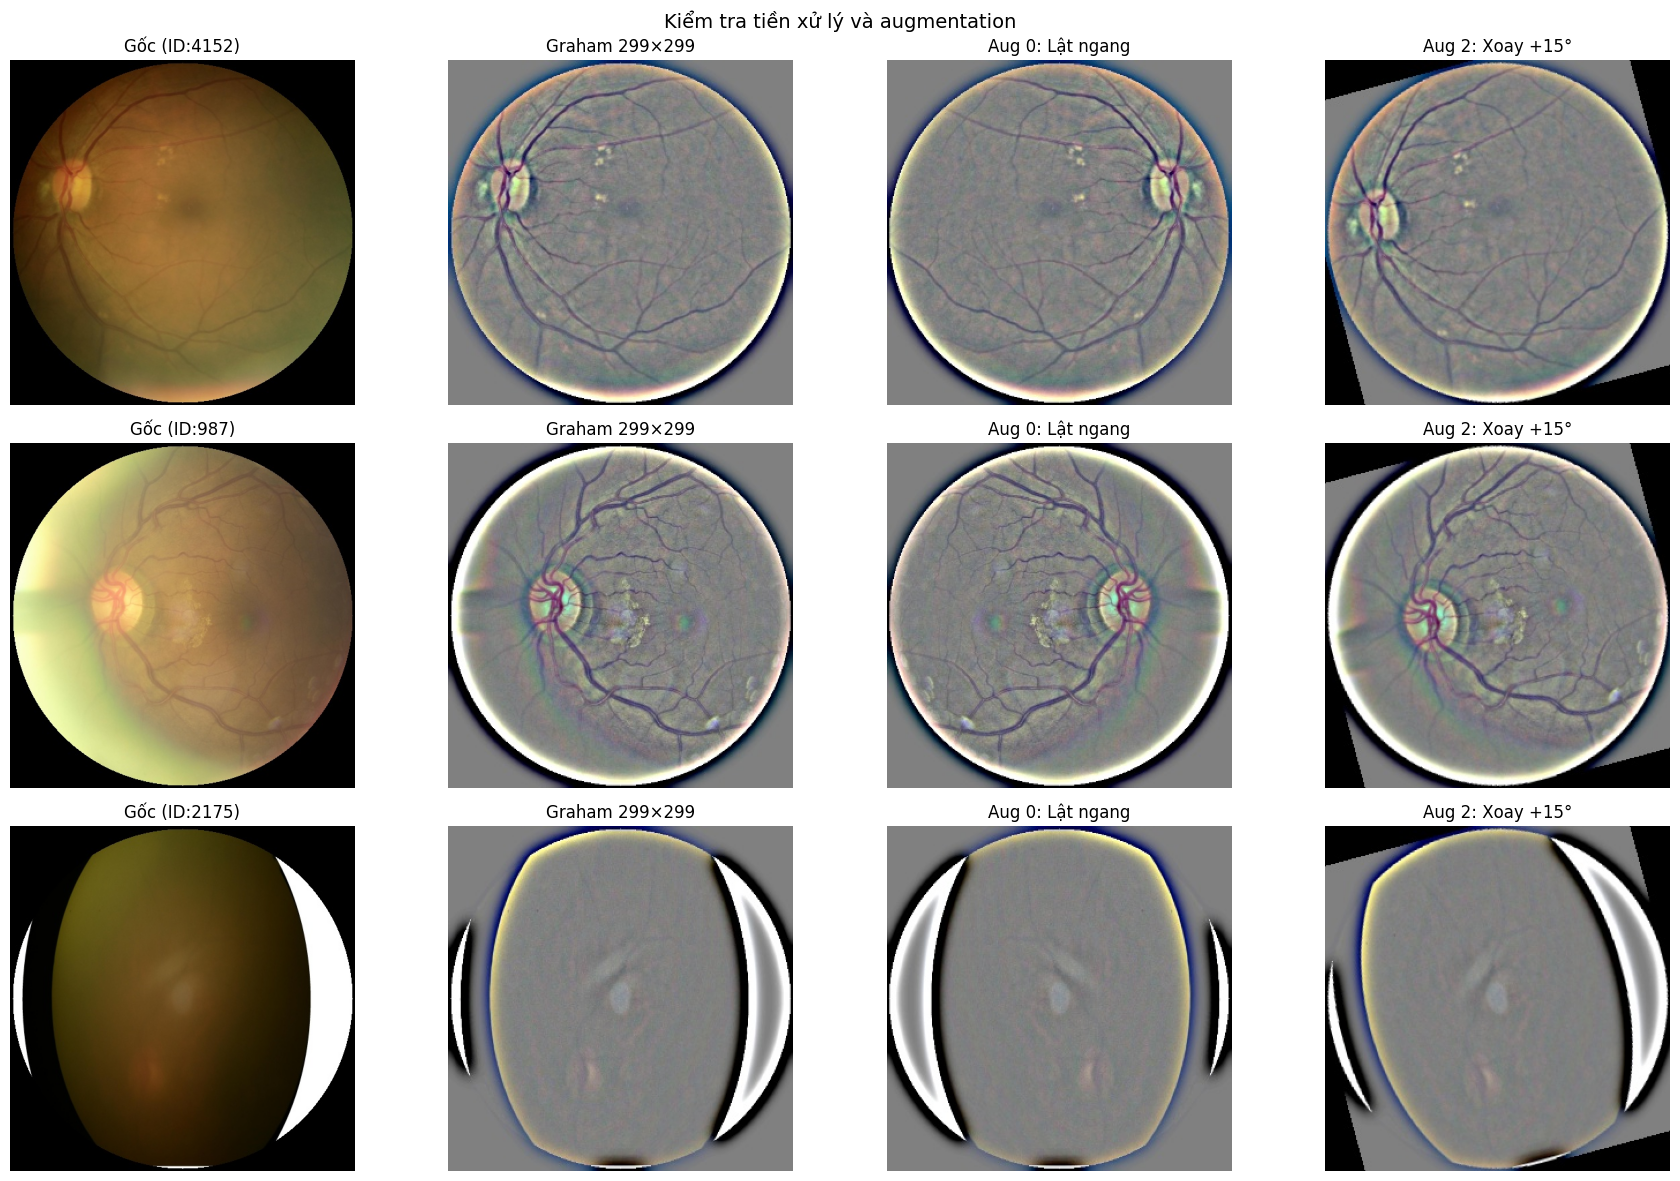

Saved: chart_preprocessing_examples.png


In [13]:
# Kiểm tra 3 bệnh nhân: so sánh gốc vs Graham vs augmented
sample_ids = train_df['ID'].sample(3, random_state=42).values

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for row_i, pid in enumerate(sample_ids):
    orig_path  = f'{IMAGE_DIR}/{pid}_left.jpg'
    base_path  = f'{OUTPUT_BASE}/train/{pid}_left.jpg'
    aug0_path  = f'{OUTPUT_BASE}/train/{pid}_left_aug0.jpg'
    aug2_path  = f'{OUTPUT_BASE}/train/{pid}_left_aug2.jpg'

    orig = Image.open(orig_path)
    base = Image.open(base_path)
    aug0 = Image.open(aug0_path)
    aug2 = Image.open(aug2_path)

    axes[row_i, 0].imshow(orig); axes[row_i, 0].set_title(f'Gốc (ID:{pid})')
    axes[row_i, 1].imshow(base); axes[row_i, 1].set_title('Graham 299×299')
    axes[row_i, 2].imshow(aug0); axes[row_i, 2].set_title('Aug 0: Lật ngang')
    axes[row_i, 3].imshow(aug2); axes[row_i, 3].set_title('Aug 2: Xoay +15°')

    for ax in axes[row_i]:
        ax.axis('off')

plt.suptitle('Kiểm tra tiền xử lý và augmentation', fontsize=14)
plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/chart_preprocessing_examples.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: chart_preprocessing_examples.png')

## 10. Tóm tắt

In [14]:
print('=== HOÀN THÀNH TIỀN XỬ LÝ ===')
print()
for split in ['train', 'val', 'test']:
    n_files = len(os.listdir(f'{OUTPUT_BASE}/{split}'))
    print(f'  {split}/: {n_files} files ảnh')

print(f'  split_metadata.csv: {len(meta_df)} rows')
print(f'  class_weights.json: {class_weights}')
print()
print('Bước tiếp theo: Chạy 03_model_inceptionresnet.ipynb')

=== HOÀN THÀNH TIỀN XỬ LÝ ===

  train/: 34342 files ảnh
  val/: 1394 files ảnh
  test/: 700 files ảnh
  split_metadata.csv: 18218 rows
  class_weights.json: {'N': 2.0739, 'D': 2.109, 'G': 15.245, 'C': 15.4631, 'A': 20.3304, 'H': 33.0694, 'M': 19.1066, 'O': 2.581}

Bước tiếp theo: Chạy 03_model_inceptionresnet.ipynb
